# Amplitude Modulation

Amplitude modulation multiplies a carrier signal by a time-varying envelope. At low rates (< 20 Hz) it is perceived as tremolo; at audio rates it creates sidebands and is called ring modulation.

| Function | Description |
| --- | --- |
| `tremolo` | Multiply carrier by `(1 − depth) + depth · sin(2πft)` — a positive-only sinusoidal LFO. At depth = 0 the signal is unchanged; at depth = 1 the amplitude swings from 0 to 2× (full AM). |
| `ring_modulate` | Multiply signal by `cos(2π · carrier_freq · t)`. Translates the spectrum by ±carrier_freq Hz; suppresses the original carrier frequency component. Also called double-sideband suppressed-carrier (DSB-SC) modulation. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.modulator import ring_modulate, tremolo

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Tremolo and ring modulation applied to a 440 Hz sine over 100 ms.

**2 × 3 grid:**

**Top row — tremolo at rate = 5 Hz, three modulation depths:**
- **Depth 0.0:** dry signal — no amplitude variation
- **Depth 0.5:** amplitude oscillates between 50 % and 100 % of the original; LFO trough is clearly visible as a dip in the envelope
- **Depth 1.0:** full AM — amplitude swings from 0 to 2×; the carrier is briefly silenced at each LFO trough

**Bottom row — ring modulation, three carrier frequencies (50 / 100 / 440 Hz):**
- The spectrum of ring modulation shows two sidebands at `440 ± carrier_freq` Hz and no energy at 440 Hz itself (carrier is suppressed)
- **50 Hz carrier:** sidebands at 390 and 490 Hz — tight cluster, subtle detuning effect
- **100 Hz carrier:** sidebands at 340 and 540 Hz — two clearly separated components
- **440 Hz carrier:** sidebands at 0 Hz (DC) and 880 Hz — the original tone is shifted one octave up plus a DC component; classic metallic ring-mod sound


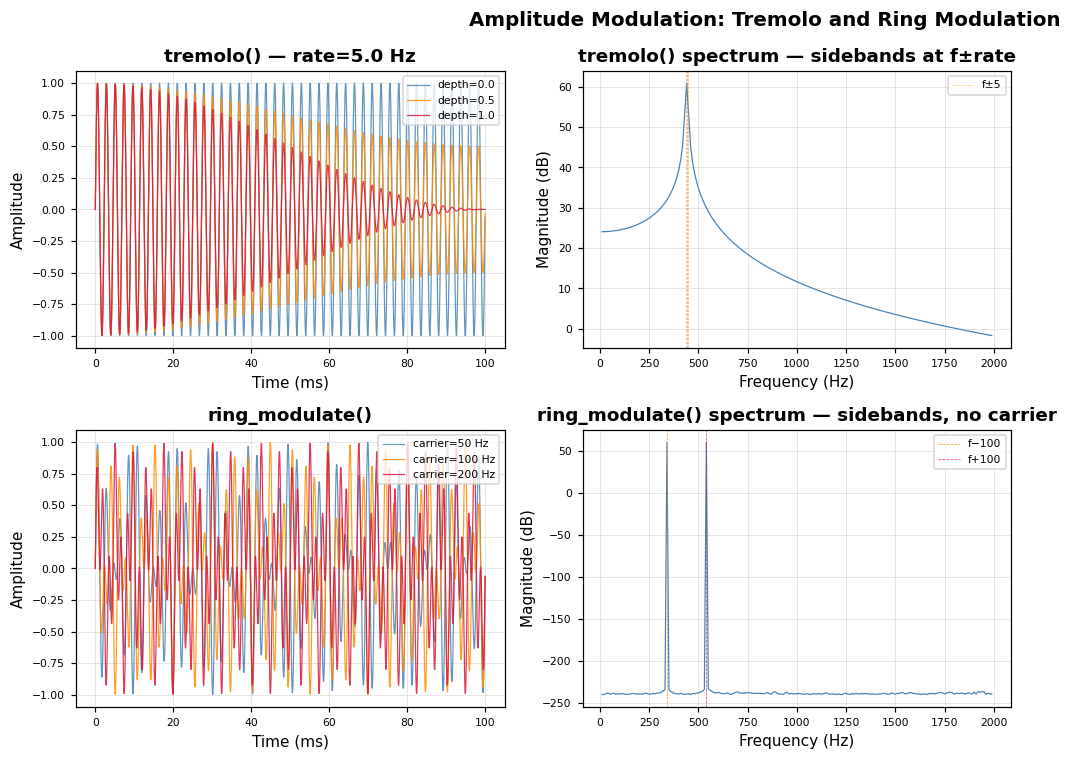

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 0.1

_, carrier = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(carrier)) / FS * 1000


def _spectrum(sig: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    freqs = np.fft.rfftfreq(len(sig), d=1.0 / FS)
    db = 20 * np.log10(np.abs(np.fft.rfft(sig)) + 1e-12)
    return freqs, db


fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# tremolo
DEPTHS = [0.0, 0.5, 1.0]
RATE = 5.0
COLORS = ["steelblue", "darkorange", "crimson"]

for depth, color in zip(DEPTHS, COLORS):
    trem = tremolo(carrier, rate=RATE, depth=depth, fs=FS)
    axes[0, 0].plot(t_ms, trem, linewidth=0.8, color=color, label=f"depth={depth}", alpha=0.85)
axes[0, 0].set_title(f"tremolo() — rate={RATE} Hz", fontweight="bold")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend(fontsize=7)

trem_full = tremolo(carrier, rate=RATE, depth=1.0, fs=FS)
freqs, db = _spectrum(trem_full)
mask = (freqs > 0) & (freqs < 2000)
axes[0, 1].plot(freqs[mask], db[mask], linewidth=0.8, color="steelblue")
axes[0, 1].axvline(FREQ, color="gray", linewidth=0.5, linestyle="--", alpha=0.6)
axes[0, 1].axvline(FREQ - RATE, color="darkorange", linewidth=0.5, linestyle="--", alpha=0.6, label=f"f±{RATE:.0f}")
axes[0, 1].axvline(FREQ + RATE, color="darkorange", linewidth=0.5, linestyle="--", alpha=0.6)
axes[0, 1].set_title("tremolo() spectrum — sidebands at f±rate", fontweight="bold")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Magnitude (dB)")
axes[0, 1].legend(fontsize=7)

axes[0, 2].set_visible(False)

# ring modulation
CARRIERS = [50.0, 100.0, 200.0]
for c_freq, color in zip(CARRIERS, COLORS):
    rm = ring_modulate(carrier, carrier_freq=c_freq, fs=FS)
    axes[1, 0].plot(t_ms, rm, linewidth=0.8, color=color, label=f"carrier={c_freq:.0f} Hz", alpha=0.85)
axes[1, 0].set_title("ring_modulate()", fontweight="bold")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].legend(fontsize=7)

C_FREQ = 100.0
rm = ring_modulate(carrier, carrier_freq=C_FREQ, fs=FS)
freqs, db = _spectrum(rm)
mask = (freqs > 0) & (freqs < 2000)
axes[1, 1].plot(freqs[mask], db[mask], linewidth=0.8, color="steelblue")
for f, label, color in [(FREQ - C_FREQ, f"f−{C_FREQ:.0f}", "darkorange"), (FREQ + C_FREQ, f"f+{C_FREQ:.0f}", "crimson")]:
    axes[1, 1].axvline(f, color=color, linewidth=0.5, linestyle="--", alpha=0.8, label=label)
axes[1, 1].set_title(f"ring_modulate() spectrum — sidebands, no carrier", fontweight="bold")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Magnitude (dB)")
axes[1, 1].legend(fontsize=7)

axes[1, 2].set_visible(False)

for ax in [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]:
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("Amplitude Modulation: Tremolo and Ring Modulation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Tremolo is slow AM (< 20 Hz) — you hear a pulsing volume. Ring modulation is fast AM — the carrier frequency disappears and sidebands appear.

| Effect | Carrier freq | Result |
| --- | --- | --- |
| Tremolo | 5 Hz | Amplitude pulsing |
| Ring mod | 100 Hz | Sidebands at 340 Hz and 540 Hz |


In [3]:
from IPython.display import Audio, display

DUR_A      = 2.0
_, car_a   = generate_sine(freq=440.0, fs=FS, duration=DUR_A)

trem_a = tremolo(car_a, rate=5.0, depth=0.9, fs=FS)
ring_a = ring_modulate(car_a, carrier_freq=100.0, fs=FS)

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Clean carrier at 440 Hz")
display(Audio(norm(car_a), rate=FS))
print("Tremolo (rate=5 Hz, depth=0.9) — slow amplitude pulsing")
display(Audio(norm(trem_a), rate=FS))
print("Ring modulation (100 Hz) — sidebands at 340 and 540 Hz, metallic/clangorous")
display(Audio(norm(ring_a), rate=FS))

Clean carrier at 440 Hz


Tremolo (rate=5 Hz, depth=0.9) — slow amplitude pulsing


Ring modulation (100 Hz) — sidebands at 340 and 540 Hz, metallic/clangorous
